# Computer Vision (Image operators and filters)

By the end of this lab, you will get hands on experience working with:

*   Image Handling
*   Image Manipulation
*   Histogram and Histogram Equalization
*   Basic filtering techniques

<!-- ### **Remember this is a graded exercise.** -->

**Reminder**:

*   For every plot, make sure you provide appropriate titles, axis labels, legends, wherever applicable.
*   Add sufficient comments and explanations wherever necessary.

---


In [63]:
# Loading necessary libraries (Feel free to add new libraries if you need for any computation)

import numpy as np
from matplotlib import pyplot as plt
from skimage import data, exposure, filters, io, morphology 

# Channels and color spaces

### **Exercise: Image Creation and Color Manipulation**

*   Create a 100 x 100 image for each of the below visualization

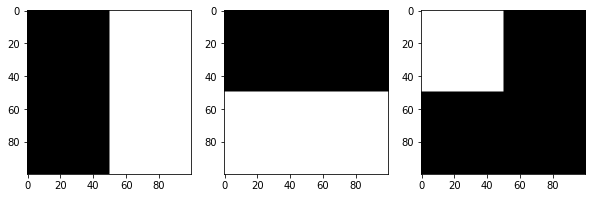

*   Visualize the created images in a 1 x 3 subplot using matplotlib.


In [64]:
# solution



*   Use the above three images to create the following image

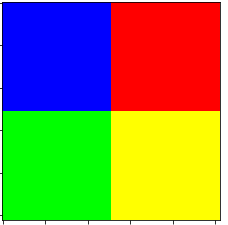
*Hint: Remember channels and color spaces*

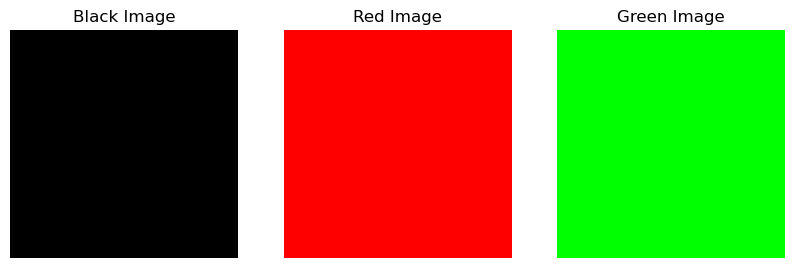

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# Create 100x100 images with different colors
image1 = np.zeros((100, 100, 3), dtype=np.uint8)  # Black image
image2 = np.full((100, 100, 3), [255, 0, 0], dtype=np.uint8)  # Red image
image3 = np.full((100, 100, 3), [0, 255, 0], dtype=np.uint8)  # Green image

# Display images
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
axes[0].imshow(image1)
axes[0].set_title("Black Image")
axes[1].imshow(image2)
axes[1].set_title("Red Image")
axes[2].imshow(image3)
axes[2].set_title("Green Image")

for ax in axes:
    ax.axis("off")

plt.show()


### **Exercise: Color Manipulation**

*   Read the image 'sillas.jpg' from the images folder

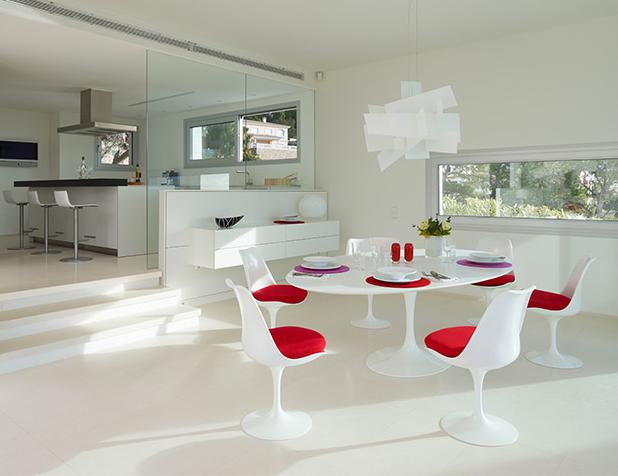

*   Extract individual channels and plot them using matplotlib subplot.



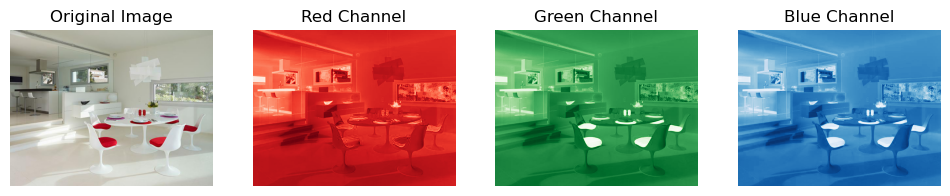

In [66]:
from skimage import io

# Load the image
sillas_img = io.imread(r"C:\Users\torre\Desktop\lab-computer-vision-main\images\sillas.jpg")

# Extract channels
red_channel = sillas_img[:, :, 0]
green_channel = sillas_img[:, :, 1]
blue_channel = sillas_img[:, :, 2]

# Plot the channels
fig, axes = plt.subplots(1, 4, figsize=(12, 5))
axes[0].imshow(sillas_img)
axes[0].set_title("Original Image")
axes[1].imshow(red_channel, cmap="Reds")
axes[1].set_title("Red Channel")
axes[2].imshow(green_channel, cmap="Greens")
axes[2].set_title("Green Channel")
axes[3].imshow(blue_channel, cmap="Blues")
axes[3].set_title("Blue Channel")

for ax in axes:
    ax.axis("off")

plt.show()




*   The color **red** looks too bright for the eyes. Isn't it?? Lets change the color and see how it appears.
    *    Create a new image where everything that is **'red' is changed to 'blue'**.
*   Visualize the original image and the created image using matplotlib subplot.

In [67]:
# solution



# Image Manipulation

### **Exercise: Image Operators**

*   You can find images 'model.png' and 'coat.png' in the images folder (First two images of the below visualization). Your task is to create an image from the given two images such a way that the model is wearing the coat (Third image in the visualization).
*   You can also find different textures in the images folder. Your task is to change the coat texture to any one of the given textures.
*   Visualize the images similar to the given visualization.

*Hint: Think masks!!!*

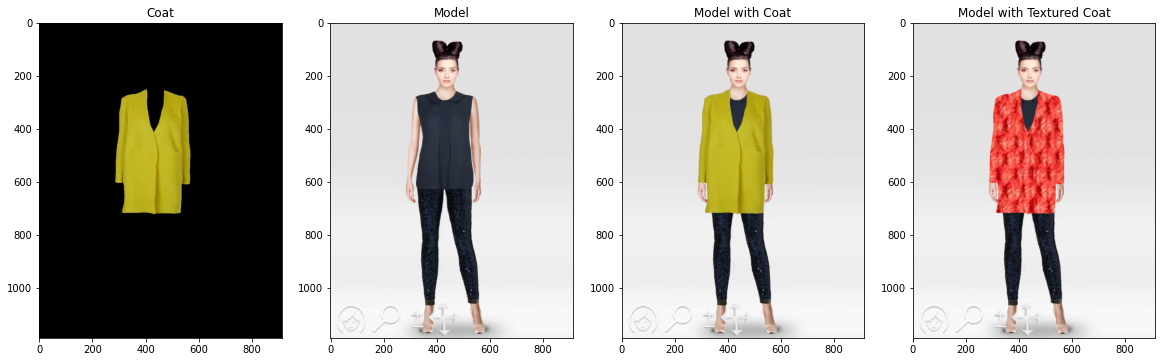

In [68]:
from skimage import img_as_ubyte

# Load images
model = io.imread(r"C:\Users\torre\Desktop\lab-computer-vision-main\images\model.png")
coat = io.imread(r"C:\Users\torre\Desktop\lab-computer-vision-main\images\coat.png")
texture = io.imread(r"C:\Users\torre\Desktop\lab-computer-vision-main\images\texture.png")

# Convert to grayscale for masking
mask = coat[:, :, 0] > 0  # Assume non-black areas are coat

# Apply coat on the model
model[mask] = coat[mask]

# Apply texture to coat region
model[mask] = texture[mask % texture.shape[0], mask % texture.shape[1]]

# Display
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(coat)
ax[0].set_title("Original Coat")
ax[1].imshow(model)
ax[1].set_title("Model Wearing Coat with Texture")
for a in ax:
    a.axis("off")

plt.show()




ValueError: shape mismatch: value array of shape (1188,915,3) could not be broadcast to indexing result of shape (108369,4)

# Contrast Enhancement

### **Exercise: Histogram Computation**

*   Read the **'astronaut' image** from data module.
*   Convert the image to grayscale.
*   Compute the **histogram of the image.** *Hint: histogram function is available in skimage.exposure package*
*   Plot the histogram using matplotlib plot.




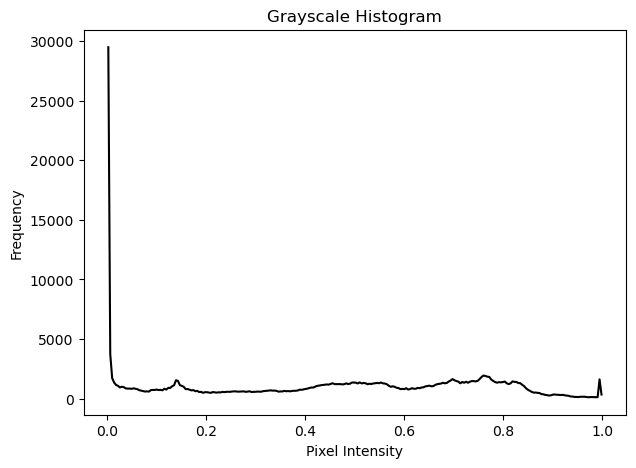

In [ ]:
from skimage import color, exposure

# Load astronaut image
astronaut_img = data.astronaut()

# Convert to grayscale
gray_astronaut = color.rgb2gray(astronaut_img)

# Compute histogram
hist, bins = exposure.histogram(gray_astronaut)

# Plot histogram
plt.figure(figsize=(7, 5))
plt.plot(bins, hist, color="black")
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()




*   Change the bin count to 8 and compute the histogram of the image and plot the computed histogram using matplotlib plot.

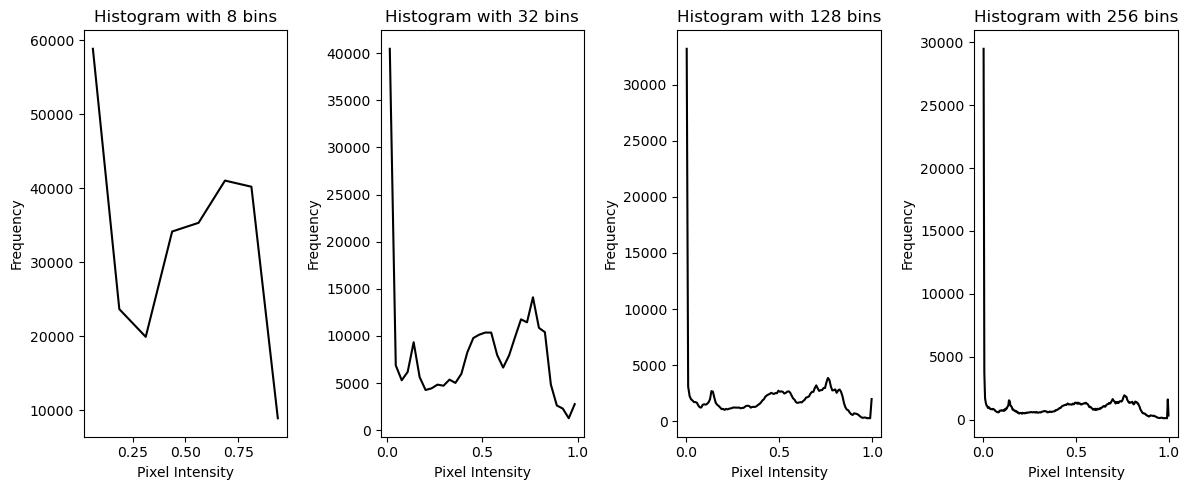

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import color, exposure, data

# Load astronaut image and convert to grayscale
astronaut_img = data.astronaut()
gray_astronaut = color.rgb2gray(astronaut_img)

# Compute histograms with different bin counts
bin_counts = [8, 32, 128, 256]  # Different bin settings

fig, ax = plt.subplots(1, len(bin_counts), figsize=(12, 5))

for i, bins in enumerate(bin_counts):
    hist, bin_edges = exposure.histogram(gray_astronaut, nbins=bins)
    
    ax[i].plot(bin_edges, hist, color="black")
    ax[i].set_title(f"Histogram with {bins} bins")
    ax[i].set_xlabel("Pixel Intensity")
    ax[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()




*   What happens when you change the bin count? Does your inference change based on the bin count? If yes, then how do you define the correct bin count.
*   What happens when the bin count is very low and what happens when it is very high?



At least in my case, it just changes the way the histogram is presented. The higher the number the better the plot will show. 


*   Compute histogram of the color image (without converting it to grayscale).
*   Plot the total histogram and also histogram for each channel (show it in a single plot with differnt legends for each histogram).


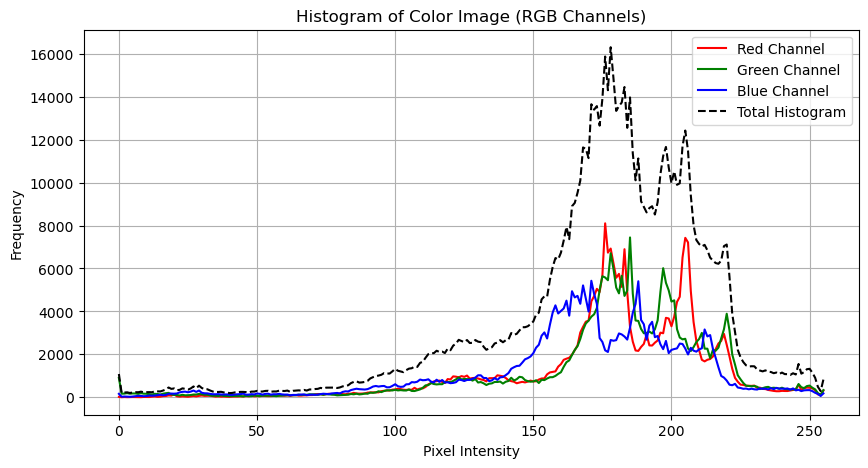

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, exposure

# Load the color image (e.g., "sillas.jpg")
image_path = r"C:\Users\torre\Desktop\lab-computer-vision-main\images\sillas.jpg"
color_image = io.imread(image_path)

# Compute histograms for each channel (Red, Green, Blue)
hist_r, bins_r = exposure.histogram(color_image[:, :, 0])  # Red channel
hist_g, bins_g = exposure.histogram(color_image[:, :, 1])  # Green channel
hist_b, bins_b = exposure.histogram(color_image[:, :, 2])  # Blue channel

# Compute total histogram by summing all three channels
hist_total = hist_r + hist_g + hist_b

# Plot the histograms
plt.figure(figsize=(10, 5))

# Plot histograms for individual channels
plt.plot(bins_r, hist_r, color='red', label='Red Channel')
plt.plot(bins_g, hist_g, color='green', label='Green Channel')
plt.plot(bins_b, hist_b, color='blue', label='Blue Channel')

# Plot total histogram
plt.plot(bins_r, hist_total, color='black', linestyle="dashed", label='Total Histogram')

# Formatting the plot
plt.title("Histogram of Color Image (RGB Channels)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.grid()

# Show the histogram plot
plt.show()




### **Exercise: Histogram Equalization**

*   Read 'aquatermi_lowcontrast.jpg' image from the images folder.
*   Compute the histogram of the image.
*   Perform histogram equalization of the image to enhance the contrast. *Hint: Use equalize_hist function available in skimage.exposure*
*   Also compute histogram of the equalized image.
*   Use 2 x 2 subplot to show the original image and the enhanced image along with the corresponding histograms.



c:\Users\torre\anaconda3\Lib\site-packages\skimage\_shared\utils.py:438: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)


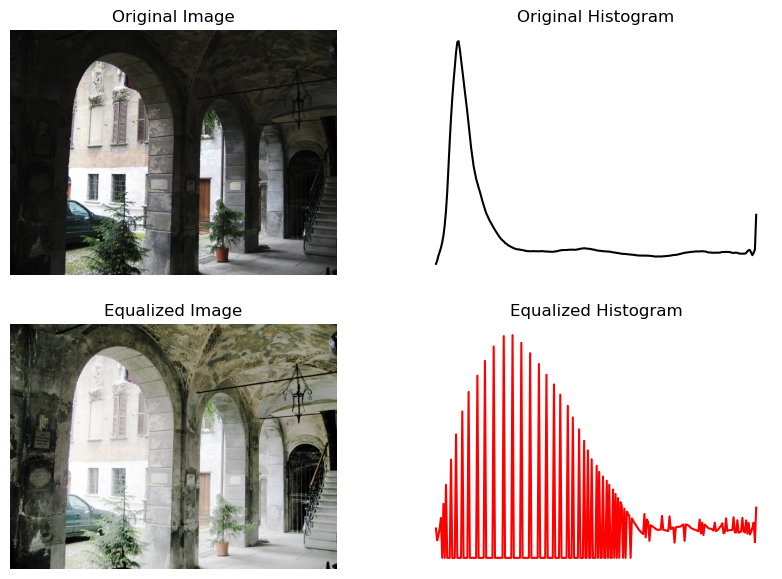

In [74]:
# Load image
low_contrast_img = io.imread(r"C:\Users\torre\Desktop\lab-computer-vision-main\images\aquatermi_lowcontrast.jpg")

# Compute histogram
hist, bins = exposure.histogram(low_contrast_img)

# Perform histogram equalization
equalized_img = exposure.equalize_hist(low_contrast_img)

# Compute histogram after equalization
equalized_hist, equalized_bins = exposure.histogram(equalized_img)

# Display results
fig, ax = plt.subplots(2, 2, figsize=(10, 7))

ax[0, 0].imshow(low_contrast_img, cmap="gray")
ax[0, 0].set_title("Original Image")
ax[0, 1].plot(bins, hist, color="black")
ax[0, 1].set_title("Original Histogram")

ax[1, 0].imshow(equalized_img, cmap="gray")
ax[1, 0].set_title("Equalized Image")
ax[1, 1].plot(equalized_bins, equalized_hist, color="red")
ax[1, 1].set_title("Equalized Histogram")

for a in ax.ravel():
    a.axis("off")

plt.show()





*   The above function in skimage.exposure uses cdf and interpolation technique to normalize the histogram. How is it different from linear contrast stretch?


**Solution**

It basically makes the colors brighter and easier to see. 

...

### **Exercise: Linear Contrast Stretch**

*   Write a function to compute the linear contrast stretch (Do not use an inbuilt function). 
*   Provide grayscale image array and bin count as parameters to the function and return the enhanced image array.
*   Use a 2 x 2 plot to visualize the original image, histogram, enhanced image and the corresponding histogram.



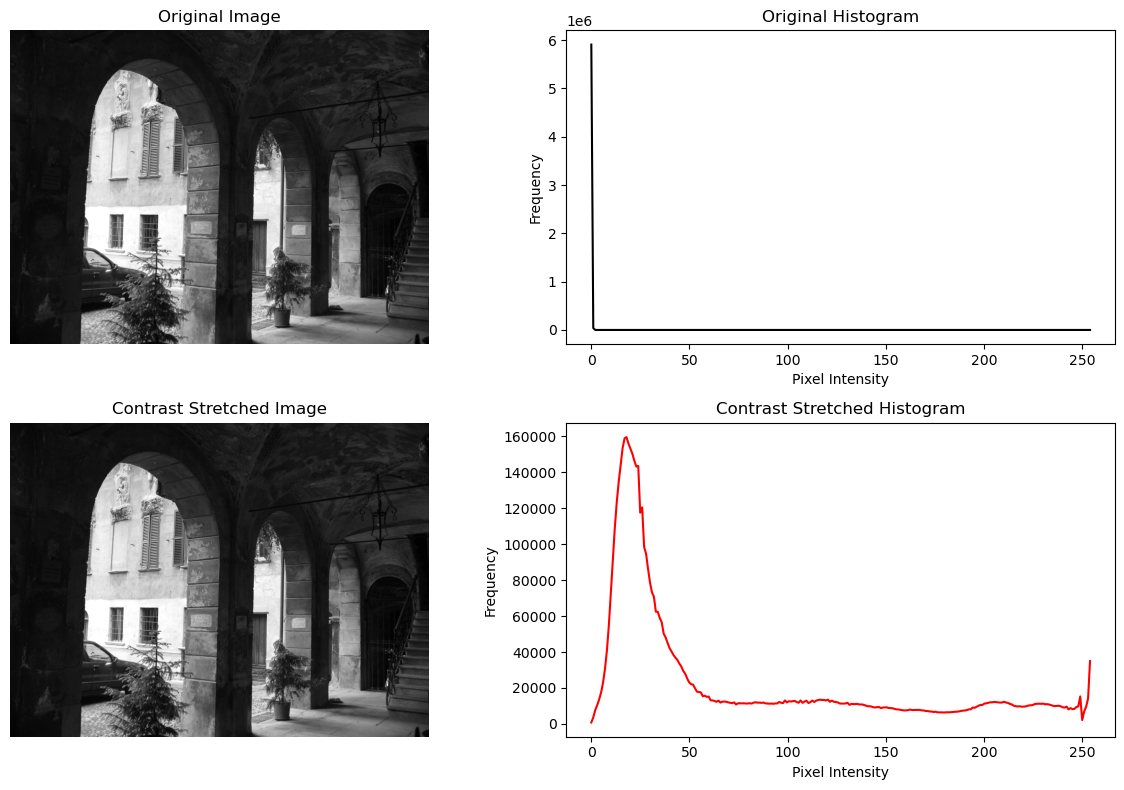

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, exposure

# Load the grayscale image (aquatermi_lowcontrast.jpg)
image_path = r"C:\Users\torre\Desktop\lab-computer-vision-main\images\aquatermi_lowcontrast.jpg"
gray_image = io.imread(image_path, as_gray=True)

# Function to perform Linear Contrast Stretching
def linear_contrast_stretch(image, bins=256):
    # Get the min and max pixel values
    min_val = np.min(image)
    max_val = np.max(image)

    # Apply the linear contrast stretch formula
    stretched_image = (image - min_val) / (max_val - min_val) * 255
    stretched_image = np.clip(stretched_image, 0, 255).astype(np.uint8)

    # Compute histograms before and after enhancement
    original_hist, original_bins = np.histogram(image, bins=bins, range=(0, 255))
    stretched_hist, stretched_bins = np.histogram(stretched_image, bins=bins, range=(0, 255))

    return stretched_image, original_hist, original_bins, stretched_hist, stretched_bins

# Perform Linear Contrast Stretching
stretched_image, original_hist, original_bins, stretched_hist, stretched_bins = linear_contrast_stretch(gray_image)

# Plot original image, histogram, enhanced image, and new histogram
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Original Image
ax[0, 0].imshow(gray_image, cmap="gray")
ax[0, 0].set_title("Original Image")
ax[0, 0].axis("off")

# Original Histogram
ax[0, 1].plot(original_bins[:-1], original_hist, color='black')
ax[0, 1].set_title("Original Histogram")
ax[0, 1].set_xlabel("Pixel Intensity")
ax[0, 1].set_ylabel("Frequency")

# Stretched Image
ax[1, 0].imshow(stretched_image, cmap="gray")
ax[1, 0].set_title("Contrast Stretched Image")
ax[1, 0].axis("off")

# Stretched Histogram
ax[1, 1].plot(stretched_bins[:-1], stretched_hist, color='red')
ax[1, 1].set_title("Contrast Stretched Histogram")
ax[1, 1].set_xlabel("Pixel Intensity")
ax[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()




# Filters

### **Exercise: Mean Filter**

*   Load the **coins** image from the data module.
*   Define a disk structuring element (selem) of radius 20. *Hint: Structuring elements are defined in the skimage.morphology module*
*   Use mean filter using the created selem. *Hint: The mean filter is available in skimage.filters.rank module*
*   Increase the radius of the selem by 10 and apply the mean filter.
*   Reduce the radius of the selem by 10 and apply the mean filter.
*   Visualize all the smoothened images along with the original image.




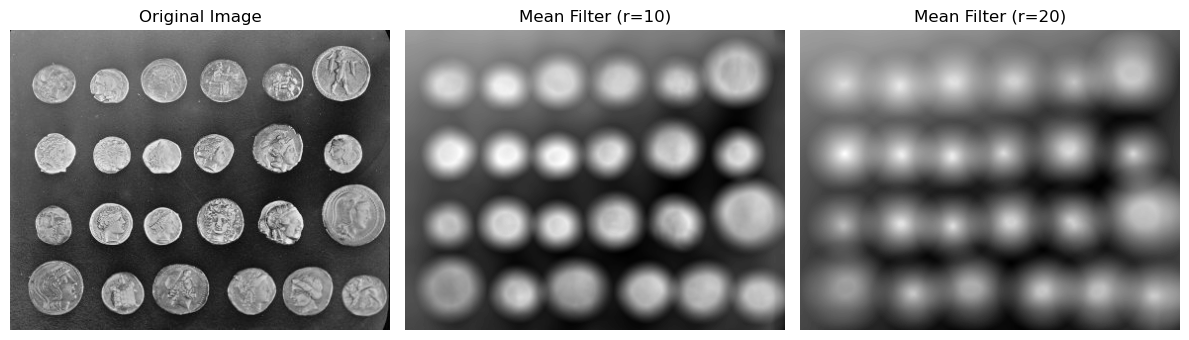

In [82]:
from skimage import data, img_as_ubyte
from skimage.morphology import disk
from skimage.filters.rank import mean

# Load the "coins" image from skimage
coins_img = data.coins()

# Convert image to uint8 (required for rank filters)
coins_img = img_as_ubyte(coins_img)

# Define structuring elements (disk-shaped)
selem1 = disk(10)  # Small disk
selem2 = disk(20)  # Larger disk

# Apply mean filter correctly
mean_filtered1 = mean(coins_img, footprint=selem1)
mean_filtered2 = mean(coins_img, footprint=selem2)

# Display results
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
ax[0].imshow(coins_img, cmap="gray")
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(mean_filtered1, cmap="gray")
ax[1].set_title("Mean Filter (r=10)")
ax[1].axis("off")

ax[2].imshow(mean_filtered2, cmap="gray")
ax[2].set_title("Mean Filter (r=20)")
ax[2].axis("off")

plt.tight_layout()
plt.show()


*   Use different selem (square, rectangle, star, diamond) to view the behaviour of the mean filter (It is not necessary to repeat with different sizes; it is sufficient to show the one with optimal parameter).
*   Create a 2 x n subplot to show the selem in the first row and the corresponding smoothened image in the second row.

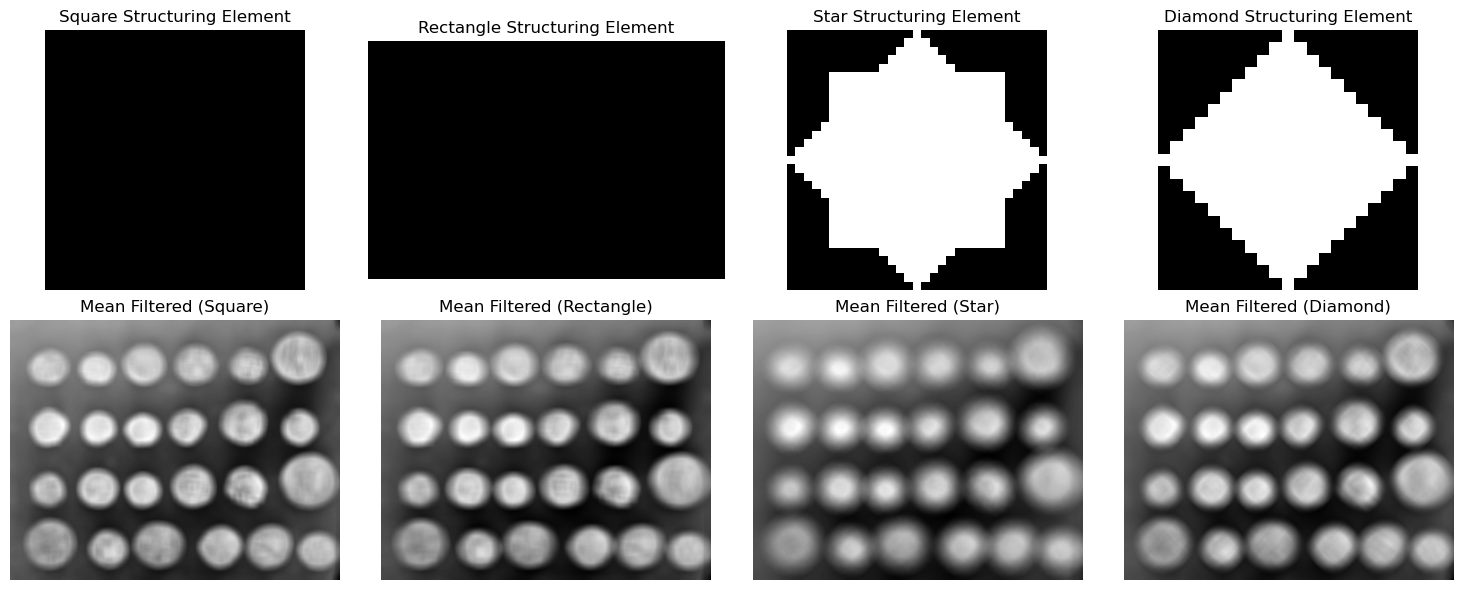

In [84]:
# Re-load the "coins" image from skimage
from skimage import data, img_as_ubyte
from skimage.morphology import square, rectangle, star, diamond
from skimage.filters.rank import mean

# Load the coins image and convert to uint8
coins_img = data.coins()
coins_img = img_as_ubyte(coins_img)

# Define different structuring elements (selem)
selem_shapes = {
    "Square": square(10),
    "Rectangle": rectangle(10, 15),
    "Star": star(10),
    "Diamond": diamond(10)
}

# Apply mean filter with each structuring element
filtered_images = {name: mean(coins_img, footprint=selem) for name, selem in selem_shapes.items()}

# Create a 2 x n subplot (n = number of structuring elements)
fig, ax = plt.subplots(2, len(selem_shapes), figsize=(15, 6))

# Plot structuring elements in the first row
for i, (name, selem) in enumerate(selem_shapes.items()):
    ax[0, i].imshow(selem, cmap="gray")
    ax[0, i].set_title(f"{name} Structuring Element")
    ax[0, i].axis("off")

# Plot filtered images in the second row
for i, (name, filtered_img) in enumerate(filtered_images.items()):
    ax[1, i].imshow(filtered_img, cmap="gray")
    ax[1, i].set_title(f"Mean Filtered ({name})")
    ax[1, i].axis("off")

plt.tight_layout()
plt.show()




*   How does changing the radius of disk affect the smoothing functionality?

**Solution**

It looses details. 

...


*   What is the observed behaviour with difference in the structuring element?



**Solution**

There's shapes that are appearing in the images. 

...



*   What is the difference between mean filter and gaussian filter?
*   Where do you use mean filters and where do you use gaussian filters?



**Solution**

A mean filter applies uniform averaging over a local neighborhood, leading to stronger blurring and edge loss, while a Gaussian filter applies a weighted average that gives more importance to central pixels, resulting in smoother blurring with better edge preservation; mean filters are useful for removing salt-and-pepper noise in simple applications, while Gaussian filters are preferred in computer vision tasks like pre-processing for edge detection and feature extraction.

...